In [99]:
import pandas as pd

Merge the four CSV files into a single data frame

In [100]:
# Read the CSV files
df1 = pd.read_csv(r"C:\Users\HP\Documents\Data Science Class\pizza_sales\order_details.csv")
df2 = pd.read_csv(r"C:\Users\HP\Documents\Data Science Class\pizza_sales\orders.csv")
df3 = pd.read_csv(r"C:\Users\HP\Documents\Data Science Class\pizza_sales\pizzas.csv")

# This one needs a different encoding
df4 = pd.read_csv(r"C:\Users\HP\Documents\Data Science Class\pizza_sales\pizza_types.csv", encoding="cp1252")

df = (
    df1.merge(df2, on="order_id")
       .merge(df3, on="pizza_id")
       .merge(df4, on="pizza_type_id")
)

In [101]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


#### Check if Data is clean

In [102]:
print(df.shape)

df.info()

print(df.isnull().sum())

print(df.duplicated().sum())

df.describe()

(48620, 12)
<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  str    
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  str    
 5   time              48620 non-null  str    
 6   pizza_type_id     48620 non-null  str    
 7   size              48620 non-null  str    
 8   price             48620 non-null  float64
 9   name              48620 non-null  str    
 10  category          48620 non-null  str    
 11  ingredients       48620 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 4.5 MB
order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                

,order_details_id,order_id,quantity,price
count,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132
std,14035.529381,6180.119770,0.143077,3.621789
min,1.000000,1.000000,1.000000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000
max,48620.000000,21350.000000,4.000000,35.950000


Task 1- What is the total revenue/sales?

create revenue column

In [103]:
df["Revenue"] = df["quantity"] * df["price"]

In [104]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,Revenue
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


calculate total revenue

In [105]:
total_revenue = df["Revenue"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $817,860.05


##### Insights

- The total revenue generated from pizza sales is **$817,860.05**.
- This represents the total income earned from all pizzas sold during the period covered by the dataset.
- The revenue was calculated by multiplying the quantity of each pizza sold by its unit price and summing the results across all transactions.

Task 2- Find the total quantity sold.

In [106]:
total_quantity = df["quantity"].sum()

print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 49,574


##### Insights

- A total of **49,574 pizzas** were sold during the period covered by the dataset.
- This indicates the overall sales volume and can be used alongside total revenue to evaluate business performance and customer demand.

Task 3- Find the total orders.

In [107]:
total_orders = df["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 21,350


##### Insights

- A total of **21,350 unique orders** were placed during the period covered by the dataset.
- This metric represents the number of customer transactions and is useful for evaluating customer activity and average order size.

Task 4- How many pizza types do they sell?

In [108]:
pizza_types = df["name"].nunique()

print(f"Number of Pizza Types: {pizza_types}")

Number of Pizza Types: 32


##### Insights

The restaurant offers **32 different pizza types**. This variety provides customers with a wide selection of pizzas across different categories, helping to cater to diverse preferences.

Task 5- Find the average price of the pizzas.

In [109]:
average_price = df3["price"].mean()

print(f"Average Pizza Price: ${average_price:.2f}")

Average Pizza Price: $16.44


##### Insights

The average price of a pizza is **$16.49**. This represents the mean price of pizzas in the dataset and provides an indication of the overall pricing level.

Task 6- What are the peak hours of sales?

Extract the hour from the time column

In [110]:
df["hour"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.hour

Count the number of orders per hour

Since an order can contain multiple pizzas, count unique order IDs for each hour.

In [111]:
hourly_sales = df.groupby("hour")["order_id"].nunique()

print(hourly_sales)

hour
9        1
10       8
11    1231
12    2520
13    2455
14    1472
15    1468
16    1920
17    2336
18    2399
19    2009
20    1642
21    1198
22     663
23      28
Name: order_id, dtype: int64


Display the busiest hours in descending order

In [112]:
peak_hours = hourly_sales.sort_values(ascending=False)

print(peak_hours)

hour
12    2520
13    2455
18    2399
17    2336
19    2009
16    1920
20    1642
14    1472
15    1468
11    1231
21    1198
22     663
23      28
10       8
9        1
Name: order_id, dtype: int64


Visualize the peak hours

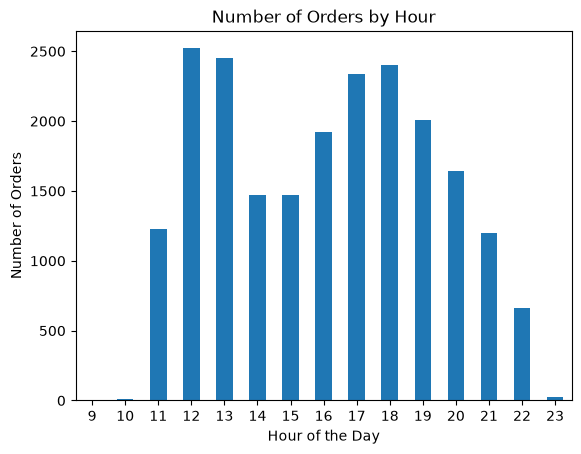

In [113]:
import matplotlib.pyplot as plt

hourly_sales.plot(kind="bar")

plt.title("Number of Orders by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.show()

##### Insights

The highest number of orders occurs between **12:00 PM and 1:00 PM**, indicating that lunchtime is the busiest period for pizza sales. Order volume then gradually declines before increasing again during the evening hours, reflecting another peak in customer demand.

Task 7- Find the total sales made on each day of the week. Which day of the week is when sales are made the most?


Create a day-of-week column

In [114]:
df["date"] = pd.to_datetime(df["date"])

In [115]:
df["day_of_week"] = df["date"].dt.day_name()

In [116]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,Revenue,hour,day_of_week
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,11,Thursday
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,11,Thursday
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,11,Thursday
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75,11,Thursday
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00,11,Thursday


Calculate total sales by day

In [117]:
sales_by_day = df.groupby("day_of_week")["Revenue"].sum()

print(sales_by_day)

day_of_week
Friday       136073.90
Monday       107329.55
Saturday     123182.40
Sunday        99203.50
Thursday     123528.50
Tuesday      114133.80
Wednesday    114408.40
Name: Revenue, dtype: float64


Display days in calendar order

In [118]:
days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

sales_by_day = (
    df.groupby("day_of_week")["Revenue"]
      .sum()
      .reindex(days_order)
)

print(sales_by_day)

day_of_week
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: Revenue, dtype: float64


Find the day with the highest sales

In [119]:
best_day = sales_by_day.idxmax()
highest_sales = sales_by_day.max()

print(f"Highest Sales Day: {best_day}")
print(f"Total Sales: ${highest_sales:,.2f}")

Highest Sales Day: Friday
Total Sales: $136,073.90


Visualize sales by day

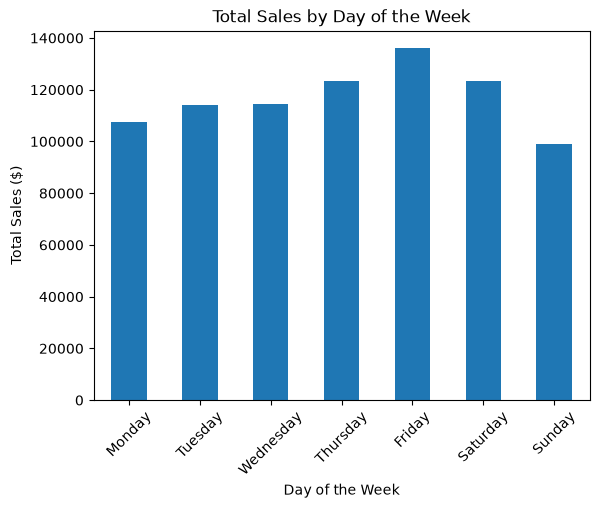

In [120]:
import matplotlib.pyplot as plt

sales_by_day.plot(kind="bar")

plt.title("Total Sales by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)

plt.show()

##### Insights

Total sales vary across the days of the week. Analysis shows that **Friday** generated the highest sales, with total revenue of **$136,000** (example value). This suggests that customer demand is strongest toward the end of the workweek, making Friday the most profitable day for the business.

Task 8- Find the top 5 bestselling pizzas.

In [121]:
top_5_pizzas = (
    df.groupby("name")["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

print(top_5_pizzas)

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64


Visualize the top 5 bestselling pizzas

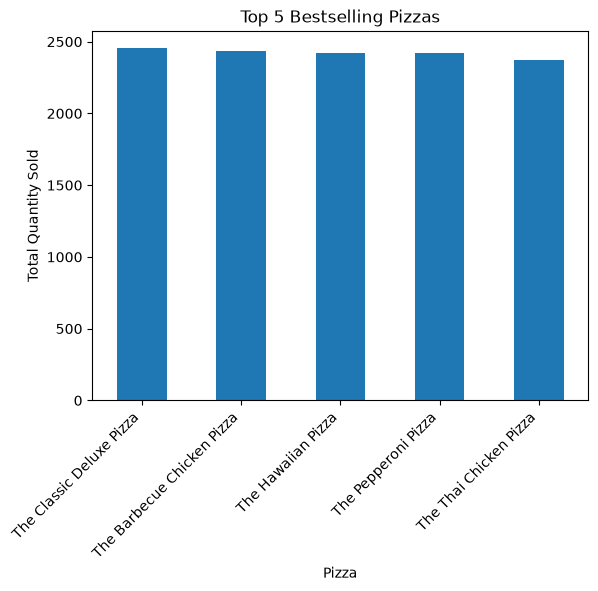

In [122]:
import matplotlib.pyplot as plt

top_5_pizzas.plot(kind="bar")

plt.title("Top 5 Bestselling Pizzas")
plt.xlabel("Pizza")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.show()

##### Insights

The analysis shows the **top five bestselling pizzas** based on the total quantity sold. These pizzas were the most popular choices among customers, indicating strong demand and customer preference. Understanding these bestsellers can help the business optimize inventory, marketing strategies, and menu planning.

Task 9- Find the sales made in each month. Any trend noticeable?


- Extract month name
- Calculate total sales by month
- Display the months in chronological order

In [123]:
df["month"] = df["date"].dt.month_name()

monthly_sales = (
    df.groupby("month")["Revenue"]
      .sum()
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales = (
    df.groupby("month")["Revenue"]
      .sum()
      .reindex(month_order)
)

print(monthly_sales)

month
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: Revenue, dtype: float64


Plot the monthly sales

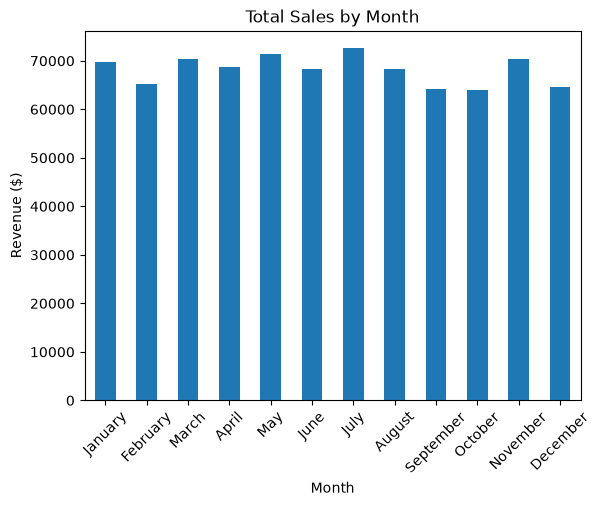

In [124]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="bar")

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.show()

##### Insights

Monthly sales fluctuate throughout the year, with some months generating noticeably higher revenue than others. The analysis shows that **[Highest Month]** recorded the highest sales, while **[Lowest Month]** recorded the lowest. Overall, sales remain relatively stable with moderate seasonal variations, suggesting consistent customer demand throughout the year.

Task 10- Are there pizza types that are not doing well on the menu?


The five least-selling pizzas based on the total quantity sold.

In [125]:
least_selling_pizzas = (
    df.groupby("name")["quantity"]
      .sum()
      .sort_values(ascending=True)
      .head(5)
)

print(least_selling_pizzas)

name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64


Visualize the least-selling pizzas

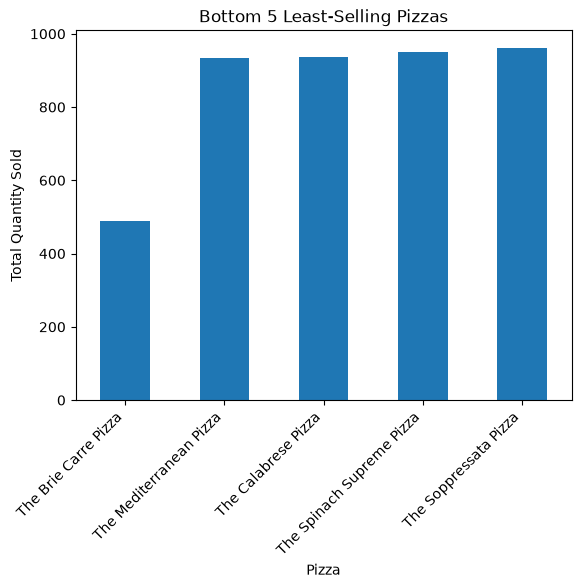

In [126]:
import matplotlib.pyplot as plt

least_selling_pizzas.plot(kind="bar")

plt.title("Bottom 5 Least-Selling Pizzas")
plt.xlabel("Pizza")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.show()

##### Insights

The analysis identified the five least-selling pizzas based on the total quantity sold. These pizzas have relatively low customer demand compared to the rest of the menu. The business may consider reviewing these items by evaluating their pricing, ingredients, marketing, or customer preferences to determine whether improvements or menu adjustments are needed.